In [91]:
import json, time, os, re
import requests
import pandas as pd
import shutil

from enum import Enum
from typing import Any, List, Dict, Optional, Union

pd.set_option('display.max_columns', None)

SCRYFALL_BASE_URL = "https://api.scryfall.com/"
CARDS_COLUMNS = [
    'name',
    'oracle_id',
    'image_uris',
    'image_uri',
    'mana_cost',
    'cmc',
    'type_line',
    'oracle_text',
    'toughness',
    'colors',
    'color_identity',
    'keywords',
    # 'legalities',
    # 'set',
    # 'set_name',
    # 'scryfall_set_uri',
    # 'rulings_uri',
    # 'prints_search_uri',
    # 'flavor_text',
    'edhrec_rank',
    # 'prices',
    'price_usd',
]
os.getcwd()

'c:\\Users\\tallo\\Documents\\programming_projects\\mtg-coding'

# Utils

In [72]:
def write_file(fpath: str, content: Union[str, bytes]) -> None:
    if not os.path.exists(os.path.dirname(fpath)):
        os.makedirs(os.path.dirname(fpath))

    if isinstance(content, str):
        with open(fpath, "wb") as f:
            f.write(content.encode("utf-8"))
    elif isinstance(content, bytes):
        with open(fpath, "wb") as f:
            f.write(content)
    
def read_file(fpath: str) -> Union[str, bytes]:
    with open(fpath, "rb") as f:
        b = f.read()
    return b.decode('utf-8') if fpath.endswith(('.json', '.csv', '.txt')) else b

# Caching and Requesting

In [99]:
class CacheType(Enum):
    JSON = "json"
    PNG = "png"

class CacheHandler:
    def __init__(self, cache_dir: str, cache_type: CacheType = CacheType.JSON):
        self.cache_dir = cache_dir
        self.cache_type = cache_type

    def _get_key_fpath(self, key: str) -> str:
        return os.path.join(self.cache_dir, f'{key}.{self.cache_type.value}')

    def get(self, key: str) -> Union[str, bytes, None]:
        fpath = self._get_key_fpath(key)
        return read_file(fpath) if os.path.exists(fpath) else None

    def set(self, key: str, value: Union[str, bytes]) -> None:
        fpath = self._get_key_fpath(key)
        write_file(fpath, value)

    def delete(self, key: str) -> None:
        fpath = self._get_key_fpath(key)
        print(fpath)
        if not os.path.exists(fpath):
            return
        os.remove(fpath)

    def clear(self) -> None:
        files = [x.split(".")[0] for x in os.listdir(self.cache_dir)]
        for f in files:
            self.delete(f)

In [48]:
class ScryfallHttpClient:
    def _get_scryfall_headers(self) -> Dict[str, str]:
        return {
            "User-Agent": "MTG-DataScience-Project/1.0",
            "Accept": "application/json;q=0.9,*/*,q=0.8",
        }
    
    def get(self, url: str, **kwargs) -> requests.Response:
        response = requests.get(url, headers=self._get_scryfall_headers(), **kwargs)
        if response.status_code != 200:
            response.raise_for_status()
        return response

In [49]:
class ScryfallDataHandler:
    def __init__(self, base_url: str, cache_handler: CacheHandler, http_client: ScryfallHttpClient):
        self.cache_handler = cache_handler
        self.http_client = http_client
        self.base_url = base_url
        self.endpoints = {
            "bulk-data": "bulk-data",
        }

    def get_bulk_data(self) -> pd.DataFrame:
        cache_contents = self.cache_handler.get(self.endpoints['bulk-data'])
        if cache_contents is not None:
            return pd.DataFrame(json.loads(cache_contents).get("data"))

        response_json = self.http_client.get(f"{self.base_url}/{self.endpoints['bulk-data']}")
        self.cache_handler.set(self.endpoints['bulk-data'], json.dumps(response_json.json(), indent=4))
        cache_contents = self.cache_handler.get(self.endpoints['bulk-data'])
        return pd.DataFrame(json.loads(cache_contents).get("data"))

    def get_oracle_cards(self) -> pd.DataFrame:
        cache_key = 'oracle-cards'
        res_df = self.get_bulk_data()
        download_uri = res_df[res_df['name'] == 'Oracle Cards']['download_uri'].iloc[0]

        cache_contents = self.cache_handler.get(cache_key)
        if cache_contents is not None:
            return pd.DataFrame(json.loads(cache_contents))

        response = self.http_client.get(download_uri, stream=True)
        self.cache_handler.set(cache_key, response.content)
        cache_contents = self.cache_handler.get(cache_key) 
        return pd.DataFrame(json.loads(cache_contents))

    def get_default_cards(self) -> pd.DataFrame:
        cache_key = 'default-cards'
        res_df = self.get_bulk_data()
        download_uri = res_df[res_df['name'] == 'Default Cards']['download_uri'].iloc[0]

        cache_contents = self.cache_handler.get(cache_key)
        if cache_contents is not None:
            return pd.DataFrame(json.loads(cache_contents))

        response = self.http_client.get(download_uri, stream=True)
        self.cache_handler.set(cache_key, response.content)
        cache_contents = self.cache_handler.get(cache_key) 
        return pd.DataFrame(json.loads(cache_contents))

# Fetching Images

In [100]:
json_cache_handler = CacheHandler("./cache/json/", cache_type=CacheType.JSON)
png_cache_handler = CacheHandler("./cache/png/", cache_type=CacheType.PNG)
scryfall_http_client = ScryfallHttpClient()
sfdh = ScryfallDataHandler(SCRYFALL_BASE_URL, json_cache_handler, scryfall_http_client)

png_cache_handler.clear()

In [106]:
cards_df = sfdh.get_oracle_cards()
cards_df['image_uri'] = cards_df['image_uris'].apply(lambda x: x.get('normal') if isinstance(x, dict) else None)
cards_df['price_usd'] = cards_df['prices'].apply(lambda x: x.get('usd') if isinstance(x, dict) else None)
cards_df.shape

(38233, 90)

In [128]:
commander_names = [x.strip() for x in read_file("./data/kaleys_commanders.txt").split("\n") if x.strip()]
commander_names[:5]

['Alexios, Deimos of Kosmos',
 'Cleopatra, Exiled Pharoah',
 'Kassandra, Eagle Bearer',
 'Zoraline, Cosmos Caller',
 'Gev, Scaled Scorch']

In [130]:
def card_name_to_cache_key(name: str) -> str:
    return re.sub(r"([,\s\"\-']+)", "_", name, count=0).lower()

def cache_card_images(image_uris: Dict[str, str], shc: ScryfallHttpClient, png_ch: CacheHandler) -> None:
    for i, (name, image_uri) in enumerate(image_uris.items()):
        cache_key = card_name_to_cache_key(name)
        if png_ch.get(cache_key) is not None:
            continue
        response = shc.get(image_uri, stream=True)
        png_ch.set(cache_key, response.content)

commander_cards_df = cards_df[cards_df['name'].isin(commander_names)]

cache_card_images(
    {r['name']: r['image_uri'] for r in commander_cards_df.to_dict('records')},
    scryfall_http_client,
    png_cache_handler,
)


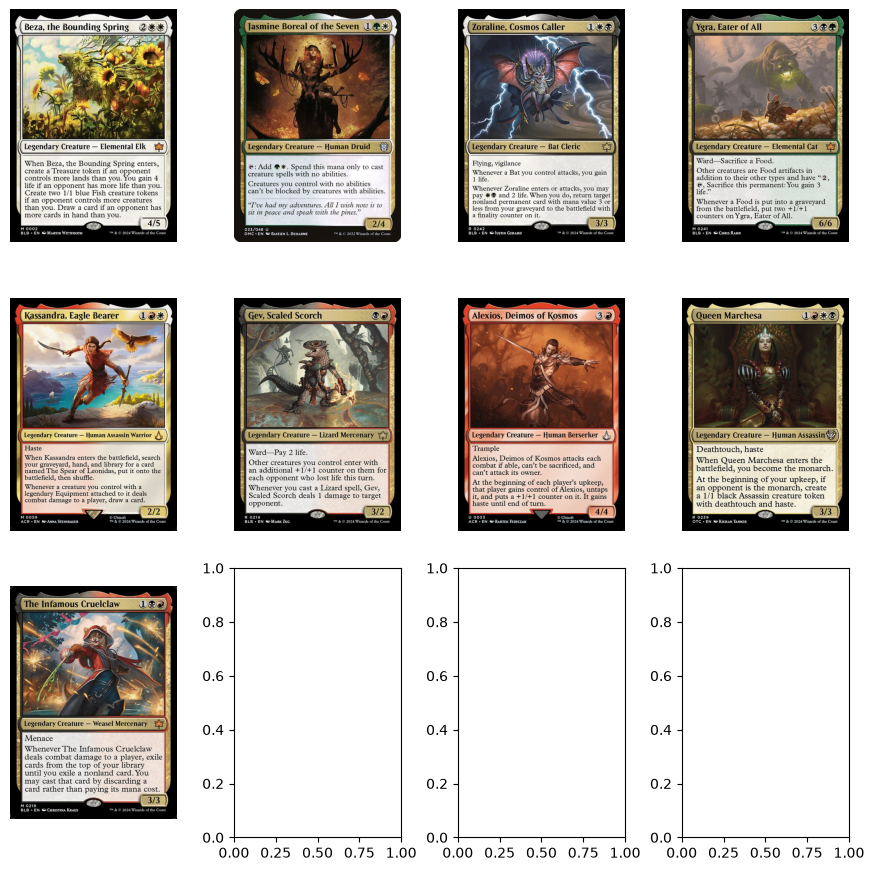

In [ ]:
import io
import tkinter as tk
from PIL import Image
from matplotlib import pyplot as plt

def get_pil_image_from_cache(name: str, png_ch: CacheHandler) -> Optional[Image.Image]:
    cache_key = card_name_to_cache_key(name)
    img_bytes = png_ch.get(cache_key)
    return Image.open(io.BytesIO(img_bytes)) if img_bytes is not None else None

images = []
for n in commander_cards_df['name'].tolist():
    img = get_pil_image_from_cache(n, png_cache_handler)
    images.append(img)

COLUMNS = 4
IMAGE_WIDTH_PX = 488
IMAGE_HEIGHT_PX = 680
ROWS = (len(images) + COLUMNS - 1) // COLUMNS

fig, axes = plt.subplots(ROWS, COLUMNS, figsize=(2.2*COLUMNS, 3*ROWS))
axes = axes.flatten()

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout(h_pad=1, w_pad=1)
plt.savefig("./data/tmp.png", dpi=300, bbox_inches='tight')
plt.show()
